In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
import os

In [2]:
if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print(f"Using device: {device}")

image_size = 128
latent_dim = 128
batch_size = 64
epochs = 50

lr = 0.0002
beta1 = 0.0
beta2 = 0.99

Using device: mps


In [3]:
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5, 0.5], [0.5, 0.5, 0.5, 0.5])
])

def rgba_loader(path):
    return Image.open(path).convert("RGBA")

dataset_roots = {
    128: "../testMohamed/archive32/PokemonImagesDBNew_square/square_128",
    256: "../testMohamed/archive32/PokemonImagesDBNew_square/square_256",
}

if image_size not in dataset_roots:
    raise ValueError(f"Unsupported image_size={image_size}. Use one of: {list(dataset_roots.keys())}")

dataset = torchvision.datasets.ImageFolder(
    root=dataset_roots[image_size],
    transform=transform,
    loader=rgba_loader
)

loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

In [4]:
class MappingNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(latent_dim,256),
            nn.ReLU(),
            nn.Linear(256,256),
            nn.ReLU(),
            nn.Linear(256,256)
        )

    def forward(self,x):
        return self.net(x)

In [5]:
class Generator(nn.Module):

    def __init__(self):

        super().__init__()

        if image_size < 16 or (image_size & (image_size - 1)) != 0:
            raise ValueError("image_size must be a power of 2 and >= 16")

        layers = [
            nn.ConvTranspose2d(256, 512, 4, 1, 0),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),
        ]

        current_size = 4
        in_ch = 512
        next_ch = 256

        while current_size < image_size:
            out_ch = max(32, next_ch)
            layers.extend([
                nn.ConvTranspose2d(in_ch, out_ch, 4, 2, 1),
                nn.BatchNorm2d(out_ch),
                nn.LeakyReLU(0.2),
            ])
            in_ch = out_ch
            next_ch //= 2
            current_size *= 2

        layers.extend([
            nn.Conv2d(in_ch, 4, 3, 1, 1),
            nn.Tanh(),
        ])

        self.net = nn.Sequential(*layers)

    def forward(self, w):
        w = w.view(-1, 256, 1, 1)
        return self.net(w)

In [6]:
class Discriminator(nn.Module):

    def __init__(self):

        super().__init__()

        if image_size < 16 or (image_size & (image_size - 1)) != 0:
            raise ValueError("image_size must be a power of 2 and >= 16")

        layers = []
        current_size = image_size
        in_ch = 4
        out_ch = 64
        first_block = True

        while current_size > 4:
            layers.append(nn.Conv2d(in_ch, out_ch, 4, 2, 1))
            if not first_block:
                layers.append(nn.BatchNorm2d(out_ch))
            layers.append(nn.LeakyReLU(0.2))

            in_ch = out_ch
            out_ch = min(out_ch * 2, 512)
            current_size //= 2
            first_block = False

        layers.extend([
            nn.Conv2d(in_ch, 1, 4, 1, 0),
            nn.Sigmoid(),
        ])

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).view(-1)

In [7]:
G = Generator().to(device)
D = Discriminator().to(device)
M = MappingNetwork().to(device)

criterion = nn.BCELoss()

opt_G = torch.optim.Adam(
    list(G.parameters()) + list(M.parameters()),
    lr=lr,
    betas=(beta1,beta2)
)

opt_D = torch.optim.Adam(
    D.parameters(),
    lr=lr,
    betas=(beta1,beta2)
)

In [8]:
for epoch in range(epochs):

    for real,_ in tqdm(loader):

        real = real.to(device)
        b = real.size(0)

        real_label = torch.ones(b).to(device)
        fake_label = torch.zeros(b).to(device)

        # Train Discriminator

        opt_D.zero_grad()

        out_real = D(real)
        loss_real = criterion(out_real,real_label)

        z = torch.randn(b,latent_dim).to(device)
        w = M(z)

        fake = G(w)

        out_fake = D(fake.detach())
        loss_fake = criterion(out_fake,fake_label)

        loss_D = loss_real + loss_fake
        loss_D.backward()
        opt_D.step()

        # Train Generator

        opt_G.zero_grad()

        out = D(fake)

        loss_G = criterion(out,real_label)
        loss_G.backward()

        opt_G.step()

    print(epoch,loss_D.item(),loss_G.item())

100%|██████████| 19/19 [00:28<00:00,  1.51s/it]


0 0.018679415807127953 10.135041236877441


100%|██████████| 19/19 [00:15<00:00,  1.23it/s]


1 0.4710134267807007 2.4525508880615234


100%|██████████| 19/19 [00:15<00:00,  1.23it/s]


...

47 1.2248891592025757 1.1543364524841309


100%|██████████| 19/19 [00:13<00:00,  1.36it/s]


48 1.339176893234253 1.7853845357894897


100%|██████████| 19/19 [00:14<00:00,  1.33it/s]


49 1.3697209358215332 0.8216862082481384


(np.float64(-0.5), np.float64(1041.5), np.float64(1041.5), np.float64(-0.5))

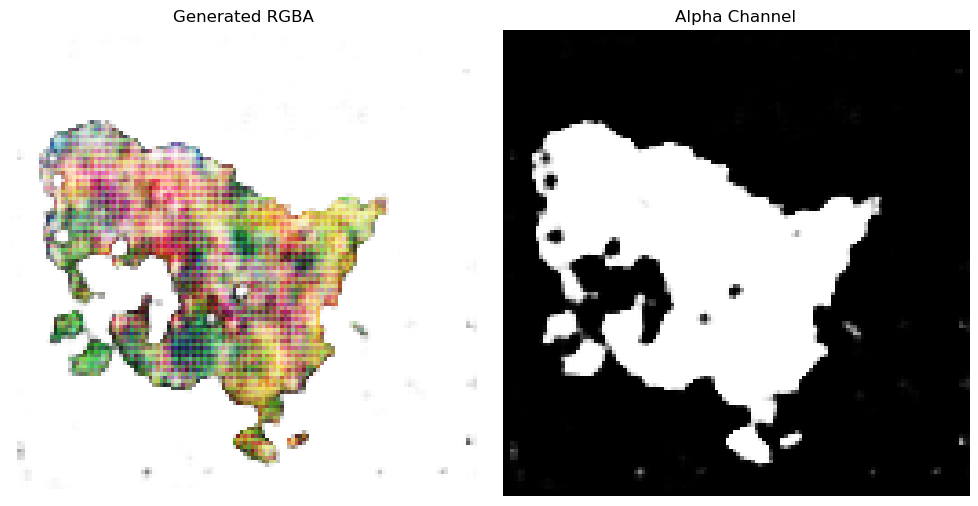

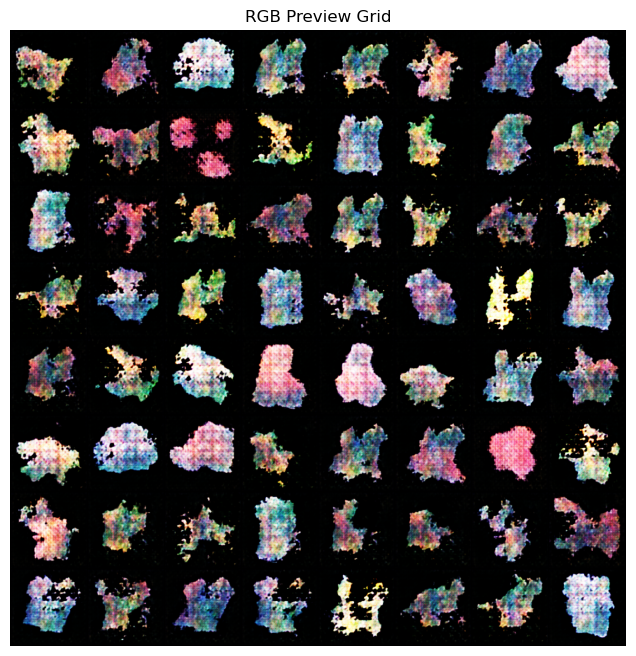

In [9]:
z = torch.randn(64, latent_dim).to(device)
w = M(z)
fake = G(w).detach().cpu()

# Convert from [-1, 1] to [0, 1] for visualization.
fake_vis = (fake + 1) / 2
fake_vis = fake_vis.clamp(0, 1)

# Show one sample as RGBA + its alpha mask.
sample_rgba = fake_vis[0].permute(1, 2, 0).numpy()
sample_alpha = fake_vis[0, 3].numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(sample_rgba)
axes[0].set_title("Generated RGBA")
axes[0].axis("off")

axes[1].imshow(sample_alpha, cmap="gray")
axes[1].set_title("Alpha Channel")
axes[1].axis("off")
plt.tight_layout()

# Optional: RGB grid preview for quick batch inspection.
rgb_grid = torchvision.utils.make_grid(fake_vis[:, :3], nrow=8)
plt.figure(figsize=(8, 8))
plt.imshow(rgb_grid.permute(1, 2, 0))
plt.title("RGB Preview Grid")
plt.axis("off")